# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [1]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


2026-04-23 21:38:41.979415: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 21:38:41.981971: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 21:38:42.015694: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 21:38:42.015739: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 21:38:42.015769: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [2]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


Dataset ready at: /home/Brayden/Desktop/446/Lab-3/UCI HAR Dataset


## 3. Load the Data


In [32]:
from pathlib import Path

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # 1. Load X_train (float32)
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)

    # 2. Load y_train (int32, zero-based)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1

    # 3. Load X_test (float32)
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype=np.float32)

    # 4. Load y_test (int32, zero-based)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data(dataset_root)

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [33]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [34]:
def build_teacher_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(512, activation="relu"),
        layers.BatchNormalization(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(128, activation="relu"),

        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 512)               287744    
                                                                 
 batch_normalization_1 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dense_17 (Dense)            (None, 256)               131328    
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_18 (Dense)            (None, 128)               32896     
                                                                 
 dense_19 (Dense)            (None, 6)                 774       
                                                      

## 6. Train the Teacher Model


In [35]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=teacher_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 2s 11ms/step - loss: 0.2892 - accuracy: 0.8854 - val_loss: 1.2368 - val_accuracy: 0.6635
Epoch 2/20
92/92 [==============================] - 1s 10ms/step - loss: 0.1310 - accuracy: 0.9529 - val_loss: 0.1839 - val_accuracy: 0.9307
Epoch 3/20
92/92 [==============================] - 1s 10ms/step - loss: 0.0890 - accuracy: 0.9662 - val_loss: 0.1592 - val_accuracy: 0.9375
Epoch 4/20
92/92 [==============================] - 1s 9ms/step - loss: 0.0710 - accuracy: 0.9726 - val_loss: 0.1169 - val_accuracy: 0.9477
Epoch 5/20
92/92 [==============================] - 1s 9ms/step - loss: 0.0642 - accuracy: 0.9750 - val_loss: 0.3025 - val_accuracy: 0.9001
Epoch 6/20
92/92 [==============================] - 1s 9ms/step - loss: 0.0777 - accuracy: 0.9714 - val_loss: 0.5354 - val_accuracy: 0.8532
Epoch 7/20
92/92 [==============================] - 1s 9ms/step - loss: 0.0649 - accuracy: 0.9753 - val_loss: 0.1480 - val_accuracy: 0.9449


### Teacher Training Curves


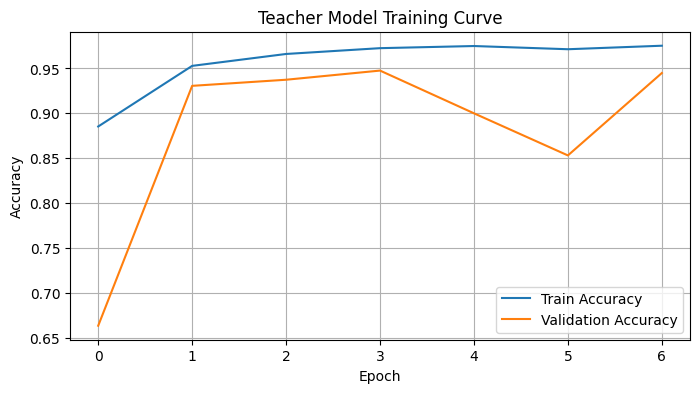

In [36]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [37]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 6ms/step - loss: 0.6791 - accuracy: 0.7216 - val_loss: 0.2670 - val_accuracy: 0.9211
Epoch 2/20
92/92 [==============================] - 0s 4ms/step - loss: 0.2696 - accuracy: 0.8963 - val_loss: 0.2087 - val_accuracy: 0.9143
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - loss: 0.1819 - accuracy: 0.9301 - val_loss: 0.1956 - val_accuracy: 0.9300
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.1429 - accuracy: 0.9437 - val_loss: 0.1422 - val_accuracy: 0.9375
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - loss: 0.1188 - accuracy: 0.9536 - val_loss: 0.1413 - val_accuracy: 0.9429
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0931 - accuracy: 0.9660 - val_loss: 0.1599 - val_accuracy: 0.9395
Epoch 7/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0961 - accuracy: 0.9621 - val_loss: 0.1502 - val_accuracy: 0.9477
Epoch 8/20
92/92 [==

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [38]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - loss: 0.0806 - accuracy: 0.9704 - val_loss: 0.1479 - val_accuracy: 0.9388
Epoch 2/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0805 - accuracy: 0.9685 - val_loss: 0.1145 - val_accuracy: 0.9504
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0670 - accuracy: 0.9759 - val_loss: 0.1490 - val_accuracy: 0.9361
Epoch 4/20
92/92 [==============================] - 0s 5ms/step - loss: 0.0683 - accuracy: 0.9752 - val_loss: 0.1382 - val_accuracy: 0.9517
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0540 - accuracy: 0.9803 - val_loss: 0.1196 - val_accuracy: 0.9511
Epoch 6/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0515 - accuracy: 0.9798 - val_loss: 0.1543 - val_accuracy: 0.9531
Epoch 7/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0657 - accuracy: 0.9759 - val_loss: 0.1220 - val_accuracy: 0.9558
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


In [39]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data

        # 1. Teacher predictions (no training)
        teacher_predictions = self.teacher(x, training=False)
    
        with tf.GradientTape() as tape:
            # 2. Student predictions (trainable)
            student_predictions = self.student(x, training=True)
    
            # 3. Hard label loss
            student_loss = self.student_loss_fn(y, student_predictions)
    
            # 4. Softened outputs (temperature scaling)
            teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature)
            student_soft = tf.nn.softmax(student_predictions / self.temperature)
    
            distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft)
    
            # 5. Combined loss
            loss = (
                self.alpha * student_loss +
                (1 - self.alpha) * distillation_loss
            )

        # Backpropagation
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
    
        # Metrics
        self.compiled_metrics.update_state(y, student_predictions)
    
        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [40]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.7220 - student_loss: 0.6705 - distillation_loss: 0.0018 - val_accuracy: 0.9157 - val_student_loss: 0.0630
Epoch 2/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.8973 - student_loss: 0.2593 - distillation_loss: 6.7761e-04 - val_accuracy: 0.9198 - val_student_loss: 0.0070
Epoch 3/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9305 - student_loss: 0.1747 - distillation_loss: 4.0777e-04 - val_accuracy: 0.9245 - val_student_loss: 0.0050
Epoch 4/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9469 - student_loss: 0.1388 - distillation_loss: 3.1063e-04 - val_accuracy: 0.9429 - val_student_loss: 0.0014
Epoch 5/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9556 - student_loss: 0.1153 - distillation_loss: 2.5261e-04 - val_accuracy: 0.9402 - val_student_loss: 9.6465e-04
Epoch 6/20
92/92 [==============================] - 1s 7ms/s

## 11. Train the Distilled Student


In [41]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 7ms/step - accuracy: 0.7094 - student_loss: 0.7048 - distillation_loss: 0.0020 - val_accuracy: 0.9082 - val_student_loss: 0.1334
Epoch 2/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.8902 - student_loss: 0.2798 - distillation_loss: 7.3065e-04 - val_accuracy: 0.9143 - val_student_loss: 0.0148
Epoch 3/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9235 - student_loss: 0.1960 - distillation_loss: 4.6477e-04 - val_accuracy: 0.9334 - val_student_loss: 0.0060
Epoch 4/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9424 - student_loss: 0.1488 - distillation_loss: 3.3103e-04 - val_accuracy: 0.9395 - val_student_loss: 0.0026
Epoch 5/20
92/92 [==============================] - 1s 6ms/step - accuracy: 0.9524 - student_loss: 0.1235 - distillation_loss: 2.7014e-04 - val_accuracy: 0.9334 - val_student_loss: 9.9601e-04
Epoch 6/20
92/92 [==============================] - 1s 6ms/s

### Distillation Training Curves


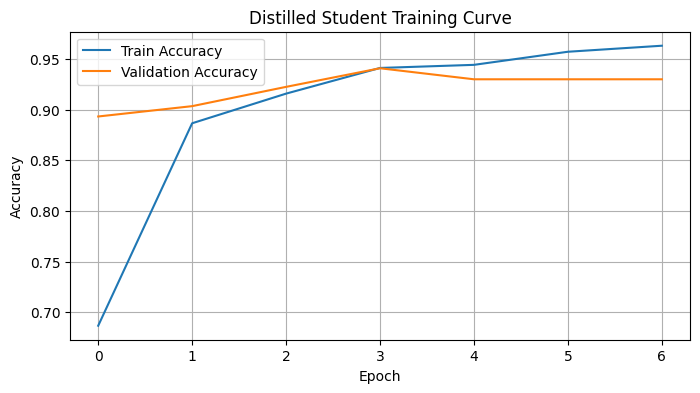

In [16]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9186

                    precision    recall  f1-score   support

           WALKING     0.8539    0.9899    0.9169       496
  WALKING_UPSTAIRS     0.9462    0.8217    0.8795       471
WALKING_DOWNSTAIRS     0.9386    0.9095    0.9238       420
           SITTING     0.9142    0.8676    0.8903       491
          STANDING     0.8781    0.9211    0.8991       532
            LAYING     0.9981    0.9888    0.9935       537

          accuracy                         0.9186      2947
         macro avg     0.9215    0.9164    0.9172      2947
      weighted avg     0.9214    0.9186    0.9182      2947



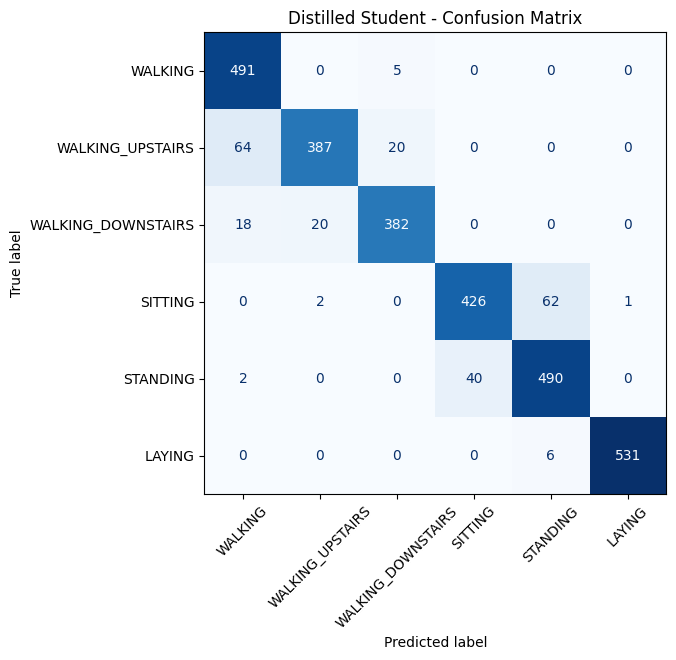

In [17]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [18]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Input quantization
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # Output dequantization
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [19]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1]]


## 15. Convert the Distilled Student to TensorFlow Lite


In [22]:
import tensorflow_model_optimization as tfmot
pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
# 2. Copy the distilled student weights into the cloned model.
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.

student_for_pruning = keras.models.clone_model(distilled_student)
student_for_pruning.set_weights(distilled_student.get_weights())
pruned_distilled_model = tfmot.sparsity.keras.prune_low_magnitude(
    student_for_pruning,
    **pruning_params
)
pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/10
92/92 [==============================] - 2s 6ms/step - loss: 0.1141 - accuracy: 0.9549 - val_loss: 0.1513 - val_accuracy: 0.9307
Epoch 2/10
92/92 [==============================] - 0s 5ms/step - loss: 0.1246 - accuracy: 0.9587 - val_loss: 0.1829 - val_accuracy: 0.9239
Epoch 3/10
92/92 [==============================] - 0s 5ms/step - loss: 0.1586 - accuracy: 0.9447 - val_loss: 0.1577 - val_accuracy: 0.9300
Epoch 4/10
92/92 [==============================] - 0s 5ms/step - loss: 0.1930 - accuracy: 0.9388 - val_loss: 0.1722 - val_accuracy: 0.9300


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [23]:
# 1. Convert model with pruning mask still attached
pruned_with_mask_tflite = tf.lite.TFLiteConverter.from_keras_model(
    pruned_distilled_model
).convert()

pruned_with_mask_size_kb = save_binary_model(
    pruned_with_mask_tflite,
    "pruned_distilled_with_mask_fp32.tflite"
)

pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(
    pruned_with_mask_tflite,
    X_test,
    y_test
)

# 2. Strip pruning wrappers
stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(
    pruned_distilled_model
)

# 3. Sparse-optimized conversion
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(
    stripped_sparse_tflite,
    "distilled_stripped_sparse_fp32.tflite"
)

stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(
    stripped_sparse_tflite,
    X_test,
    y_test
)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmp8v4bkpef/assets


INFO:tensorflow:Assets written to: /tmp/tmp8v4bkpef/assets
2026-04-23 21:49:41.588530: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:49:41.588567: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:49:41.588923: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8v4bkpef
2026-04-23 21:49:41.592361: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:49:41.592405: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8v4bkpef
2026-04-23 21:49:41.600402: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 21:49:41.602566: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:49:41.666829: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmpi692zlud/assets


INFO:tensorflow:Assets written to: /tmp/tmpi692zlud/assets


Pruned distilled model with mask accuracy: 0.9298
Pruned distilled model with mask size (KB): 319.84
Stripped sparse distilled model accuracy: 0.9298
Stripped sparse distilled model size (KB): 316.89


2026-04-23 21:49:42.445409: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:49:42.445436: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:49:42.445748: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpi692zlud
2026-04-23 21:49:42.446568: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:49:42.446579: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpi692zlud
2026-04-23 21:49:42.448398: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:49:42.465638: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpi692zlud
2026-04-23 21:49:42.474259: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 28511 m

## 17. Convert the Pruned Distilled Student Before and After Stripping


In [25]:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()

stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)

stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")

INFO:tensorflow:Assets written to: /tmp/tmpj8cu279a/assets


INFO:tensorflow:Assets written to: /tmp/tmpj8cu279a/assets
/home/Brayden/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Stripped Sparse + INT8 Accuracy: 0.9304
Stripped Sparse + INT8 Size (KB): 81.78


2026-04-23 21:51:02.206535: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:51:02.206564: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:51:02.206767: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpj8cu279a
2026-04-23 21:51:02.207543: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:51:02.207554: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpj8cu279a
2026-04-23 21:51:02.209546: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:51:02.226204: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpj8cu279a
2026-04-23 21:51:02.232540: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 25773 m

## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [28]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

# Convert distilled student to FP32 TFLite
distilled_fp32_tflite = tf.lite.TFLiteConverter.from_keras_model(
    distilled_student
).convert()

# Save + size
distilled_fp32_size_kb = save_binary_model(
    distilled_fp32_tflite,
    "distilled_fp32.tflite"
)

# Evaluate
distilled_fp32_acc, _ = evaluate_tflite_model(
    distilled_fp32_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpqzd10rkd/assets


INFO:tensorflow:Assets written to: /tmp/tmpqzd10rkd/assets
/home/Brayden/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 21:55:20.574142: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:55:20.574175: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:55:20.574378: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqzd10rkd
2026-04-23 21:55:20.575136: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:55:20.575147: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpqzd10rkd
2026-04-23 21:55:20.577022: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

INFO:tensorflow:Assets written to: /tmp/tmp4ka7w_8r/assets


INFO:tensorflow:Assets written to: /tmp/tmp4ka7w_8r/assets
2026-04-23 21:55:21.160344: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 21:55:21.160376: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 21:55:21.160578: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp4ka7w_8r
2026-04-23 21:55:21.161292: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 21:55:21.161303: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp4ka7w_8r
2026-04-23 21:55:21.162856: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 21:55:21.179923: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp4ka7w_8r
2026-04-23 21:55:21.186479: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Stripped Sparse + INT8 Accuracy: 0.9304
Stripped Sparse + INT8 Size (KB): 81.77


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [29]:

part2_results = pd.DataFrame([
    ["Distilled Student TFLite", "FP32", distilled_fp32_acc, distilled_fp32_size_kb],
    ["Pruned Distilled TFLite (with mask)", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled TFLite", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled TFLite", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Distilled Student TFLite,FP32,0.918561,316.886719
1,Pruned Distilled TFLite (with mask),FP32,0.929759,319.839844
2,Stripped Sparse Distilled TFLite,FP32 + Sparse,0.929759,316.886719
3,Stripped Sparse Distilled TFLite,INT8 + Sparse,0.930438,81.773438


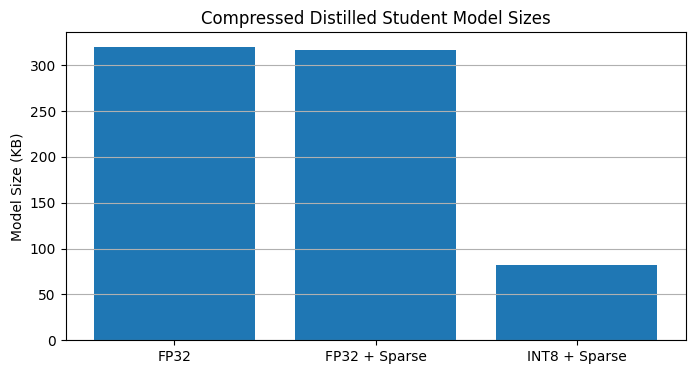

In [30]:

plt.figure(figsize=(8, 4))
plt.bar(part2_results["Format"], part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Compressed Distilled Student Model Sizes")
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Final Sparse INT8 Distilled Student


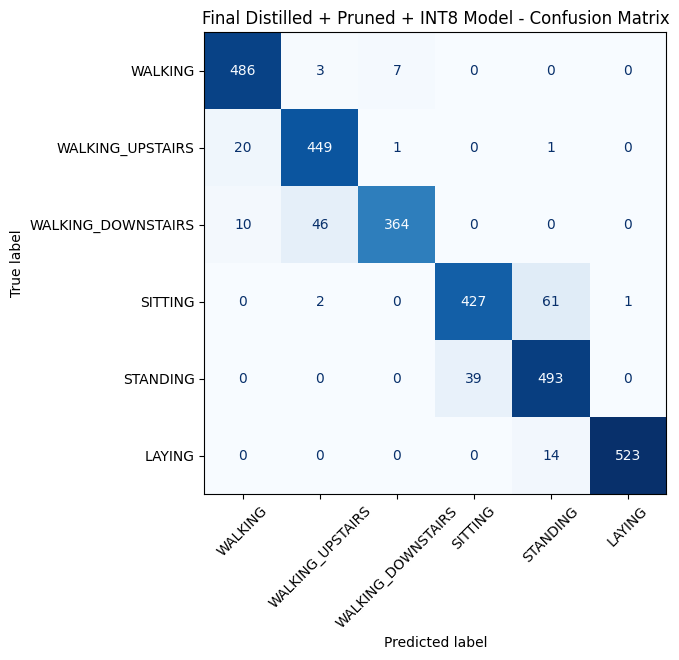

In [31]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

1. How did the baseline student compare with the distilled student?

The distilled student performed better than the baseline student because it learned from both the true labels and the teacher’s soft predictions, allowing it to generalize more effectively.

2. Did knowledge distillation help the smaller model retain performance?

Yes, it improved performance by transferring knowledge from the teacher model, helping the smaller student retain higher accuracy than when trained only on hard labels.

3. What happened to the model size after pruning and after INT8 quantization?

Pruning reduced the model size by removing unnecessary weights, and INT8 quantization further reduced it by converting weights from float32 to int8, with the combined model being the smallest.

4. Which model would you choose for Arduino deployment, and why?

The sparse INT8 model is best for Arduino because it is very small, computationally efficient, and suitable for low-power hardware.

5. Why is the final sparse INT8 model a good TinyML deployment candidate?

It is ideal for TinyML because it combines sparsity and quantization, making it lightweight, fast, and efficient while still maintaining acceptable accuracy.


## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
